In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
df=pd.read_csv("homeprices_banglore.csv")
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [12]:
from sklearn import preprocessing
sx=preprocessing.MinMaxScaler()
sy=preprocessing.MinMaxScaler()

scaled_X=sx.fit_transform(df.drop(['price'],axis='columns'))
scaled_X

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [13]:
scaled_y=sy.fit_transform(df['price'].values.reshape(-1,1))
scaled_y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [14]:
scaled_X.shape[1]

2

In [15]:
no_of_features=scaled_X.shape[1]
no_of_features

2

In [16]:
np.ones(no_of_features)

array([1., 1.])

In [17]:
import random 
random.randint(0,5) #it will generate a random value between 0 and 5

4

In [ ]:
def stochastic_gradient_descent(X,y_true,epochs,learning_rate=0.01):
    no_of_features=X.shape[1]
    w=np.ones(no_of_features)
    b=0
    total_samples=X.shape[0]

    cost_list=[]
    epoch_list=[]

    for i in range(epochs):
        random_index=random.randint(0,total_samples-1)
        sample_X=X[random_index]
        sample_y=y_true[random_index]
        y_predicted=np.dot(sample_X,w)+b    #here both sample_X and w are 1d.So we dont need to define the transpose with them.
                                            #so in this case if we use np.dot(w, sample_X) then this also correct
                                            #here basically,    np.dot(w, sample_X) == np.dot(sample_X, w)  

        w_grad = -(2/total_samples)*(sample_X.T.dot(sample_y-y_predicted))
        b_grad = -(2/total_samples)*np.sum(sample_y-y_predicted)

        w=w-learning_rate*w_grad
        b=b-learning_rate*b_grad

        cost=np.square(sample_y-y_predicted)

        if(i%10==0):
            cost_list.append(cost)
            epoch_list.append(i)

    return w,b,cost,cost_list,epoch_list

w_sgd,b_sgd,cost_sgd,cost_list_sgd,epoch_list_sgd=stochastic_gradient_descent(scaled_X,scaled_y.reshape(scaled_y.shape[0],),10000)
w_sgd,b_sgd,cost_sgd

(array([0.70642901, 0.67256349]), -0.23359776969356869, 0.003057600626811173)

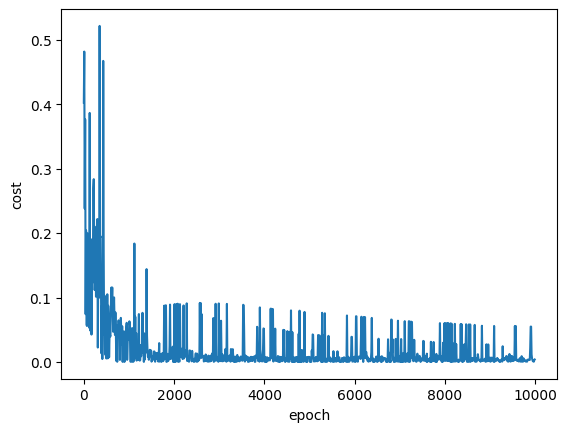

In [23]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_sgd,cost_list_sgd)

In [26]:
def predict(area,bedrooms,w,b):
    scaled_X=sx.transform([[area,bedrooms]])[0]

    scaled_price=w[0]*scaled_X[0]+w[1]*scaled_X[1]+b
    return sy.inverse_transform([[scaled_price]])

predict(2500,4,w_sgd,b_sgd)

C:\Users\User\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[124.46668462]])

In [27]:
predict(2600,4,w_sgd,b_sgd)

C:\Users\User\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[127.75523345]])